**Hotel Booking EDA**

Install and Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.dpi'] = 110

# Colour palette — used consistently in every chart
NAVY  = '#0D1B2A'
BLUE  = '#1B4F8A'
TEAL  = '#1A9988'
AMBER = '#E8A838'
ROSE  = '#D94F6B'
SAND  = '#F5EFE6'

def style_ax(ax, title='', xlabel='', ylabel=''):
    ax.set_facecolor(SAND)
    ax.set_title(title, fontsize=13, fontweight='bold', color=NAVY, pad=10)
    ax.set_xlabel(xlabel, fontsize=10, color=NAVY)
    ax.set_ylabel(ylabel, fontsize=10, color=NAVY)
    ax.tick_params(colors=NAVY)
    for spine in ax.spines.values():
        spine.set_edgecolor('#CCCCCC')
    ax.grid(axis='y', color='white', linewidth=1.2, alpha=0.8)


Load the Dataset

In [2]:
df_raw = pd.read_csv('/content/hotel_bookings.csv')

print(f"Rows    : {df_raw.shape[0]:,}")
print(f"Columns : {df_raw.shape[1]}")
print(f"Memory  : {df_raw.memory_usage(deep=True).sum() / 1024**2:.1f} MB")


Rows    : 119,390
Columns : 33
Memory  : 94.6 MB


The first look of the dataset

In [3]:
df_raw.head()

,index,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.00,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,01-07-15
1,1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.00,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,01-07-15
2,2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.00,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,02-07-15
3,3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.00,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.00,NaN,0,Transient,75.00,0,0,Check-Out,02-07-15
4,4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.00,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.00,NaN,0,Transient,98.00,0,1,Check-Out,03-07-15


Column Info - to see every column name, its data type, and how many non-null values it has

In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 33 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   index                           119390 non-null  int64  
 1   hotel                           119390 non-null  object 
 2   is_canceled                     119390 non-null  int64  
 3   lead_time                       119390 non-null  int64  
 4   arrival_date_year               119390 non-null  int64  
 5   arrival_date_month              119390 non-null  object 
 6   arrival_date_week_number        119390 non-null  int64  
 7   arrival_date_day_of_month       119390 non-null  int64  
 8   stays_in_weekend_nights         119390 non-null  int64  
 9   stays_in_week_nights            119390 non-null  int64  
 10  adults                          119390 non-null  int64  
 11  children                        119386 non-null  float64
 12  babies          

Statistical Summary of Numeric Columns

In [5]:
df_raw[['adr', 'lead_time', 'stays_in_weekend_nights',
        'stays_in_week_nights', 'adults', 'children',
        'babies', 'total_of_special_requests']].describe().round(2)

,adr,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,total_of_special_requests
count,119390.00,119390.00,119390.00,119390.00,119390.00,119386.00,119390.00,119390.00
mean,101.83,104.01,0.93,2.50,1.86,0.10,0.01,0.57
std,50.54,106.86,1.00,1.91,0.58,0.40,0.10,0.79
min,-6.38,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,69.29,18.00,0.00,1.00,2.00,0.00,0.00,0.00
50%,94.58,69.00,1.00,2.00,2.00,0.00,0.00,0.00
75%,126.00,160.00,2.00,3.00,2.00,0.00,0.00,1.00
max,5400.00,737.00,19.00,50.00,55.00,10.00,10.00,5.00


A negative ** adr min** is seen above which is not possible as prices cannot be negative.

Missing Value Analysis

In [6]:
missing = pd.DataFrame({
    'Missing Count' : df_raw.isnull().sum(),
    'Missing %'     : (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print(missing)

          Missing Count  Missing %
company          112593      94.31
agent             16340      13.69
country             488       0.41
children              4       0.00


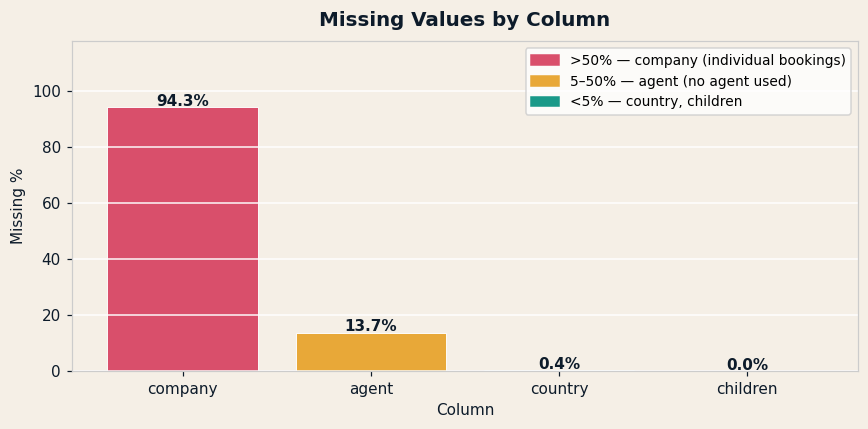

In [7]:
# Visualise
fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor(SAND)

bar_colors = [ROSE if p > 50 else AMBER if p > 5 else TEAL
              for p in missing['Missing %']]

bars = ax.bar(missing.index, missing['Missing %'],
              color=bar_colors, edgecolor='white', linewidth=0.6)

for bar, val in zip(bars, missing['Missing %']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
            f'{val:.1f}%', ha='center', fontsize=10,
            fontweight='bold', color=NAVY)

style_ax(ax, 'Missing Values by Column', 'Column', 'Missing %')
ax.set_ylim(0, missing['Missing %'].max() * 1.25)

patches = [
    mpatches.Patch(color=ROSE,  label='>50% — company (individual bookings)'),
    mpatches.Patch(color=AMBER, label='5–50% — agent (no agent used)'),
    mpatches.Patch(color=TEAL,  label='<5% — country, children'),
]
ax.legend(handles=patches, fontsize=9)
plt.tight_layout()
plt.show()

Data Cleaning

In [11]:
df = df_raw.copy()

# Fix 1: Fill missing values with correct defaults
df['children'] = df['children'].fillna(0)        # no children recorded
df['country']  = df['country'].fillna('Unknown')  # origin not captured
df['agent']    = df['agent'].fillna(0)            # no agent used
df['company']  = df['company'].fillna(0)          # individual booking

# Fix 2: Convert float → int (these are whole numbers)
df['children'] = df['children'].astype(int)
df['agent']    = df['agent'].astype(int)
df['company']  = df['company'].astype(int)

# Fix 3: Remove zero-guest rows (impossible — who booked with no guests?)
before = len(df)
df = df[(df['adults'] + df['children'] + df['babies']) > 0]
print(f"Zero-guest rows removed : {before - len(df)}")

# Fix 4: Remove impossible ADR values (negative price or > €5,000)
before = len(df)
df = df[(df['adr'] >= 0) & (df['adr'] < 5000)]
print(f"Bad ADR rows removed    : {before - len(df)}")

# Fix 5: Order months correctly (Jan→Dec instead of alphabetical)
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
df['arrival_date_month'] = pd.Categorical(
    df['arrival_date_month'], categories=month_order, ordered=True)

print(f"\n   Clean shape          : {df.shape}")
print(f"   Missing values left  : {df.isnull().sum().sum()}")

# Sanity check — this will raise an error if any missing values remain
assert df.isnull().sum().sum() == 0, "Still have missing values!"
print("   Assertion passed")


Zero-guest rows removed : 180
Bad ADR rows removed    : 2

   Clean shape          : (119208, 33)
   Missing values left  : 0
   Assertion passed


Feature Enginnering

In [12]:
# 1. Total nights per stay
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

# 2. Revenue per booking (ADR × nights)
df['total_revenue'] = df['adr'] * df['total_nights']

# 3. Total guests per booking
df['total_guests'] = df['adults'] + df['children'] + df['babies']

# 4. Did the guest get the room they booked?
df['room_match'] = (df['reserved_room_type'] == df['assigned_room_type'])

# 5. Lead time grouped into meaningful buckets
bins   = [0, 7, 30, 90, 180, 365, 737]
labels = ['≤7 days','8-30 days','31-90 days',
          '91-180 days','181-365 days','>365 days']
df['lead_bucket'] = pd.cut(df['lead_time'], bins=bins,
                           labels=labels, right=True)

# 6. Readable guest type
df['guest_type'] = df['is_repeated_guest'].map(
    {0: 'New Guest', 1: 'Repeat Guest'})

# Preview
new_cols = ['total_nights','total_revenue','total_guests',
            'room_match','lead_bucket','guest_type']
print(df[new_cols].head(8))
print(f"\nguest_type counts:\n{df['guest_type'].value_counts()}")
print(f"\nlead_bucket counts:\n{df['lead_bucket'].value_counts().sort_index()}")


   total_nights  total_revenue  total_guests  room_match   lead_bucket  \
0             0           0.00             2        True  181-365 days   
1             0           0.00             2        True     >365 days   
2             1          75.00             1       False       ≤7 days   
3             1          75.00             1        True     8-30 days   
4             2         196.00             2        True     8-30 days   
5             2         196.00             2        True     8-30 days   
6             2         214.00             2        True           NaN   
7             2         206.00             2        True     8-30 days   

  guest_type  
0  New Guest  
1  New Guest  
2  New Guest  
3  New Guest  
4  New Guest  
5  New Guest  
6  New Guest  
7  New Guest  

guest_type counts:
guest_type
New Guest       115454
Repeat Guest      3754
Name: count, dtype: int64

lead_bucket counts:
lead_bucket
≤7 days         13371
8-30 days       18945
31-90 days      29

Univariate Analysis

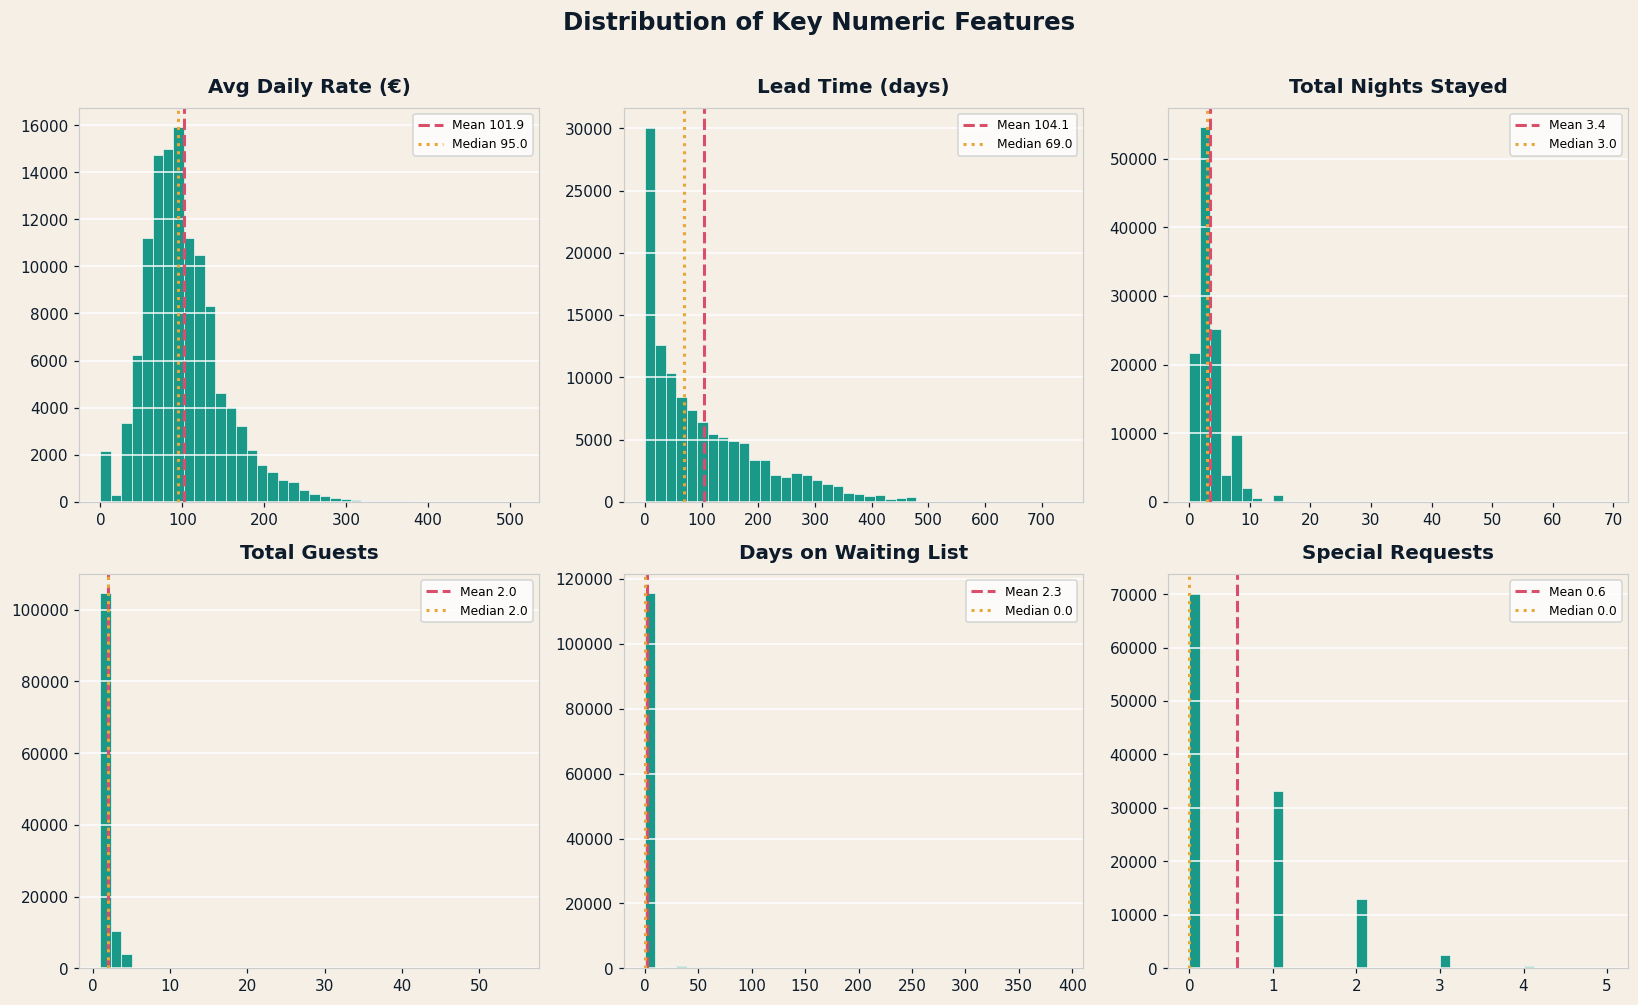

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.patch.set_facecolor(SAND)
fig.suptitle('Distribution of Key Numeric Features',
             fontsize=16, fontweight='bold', color=NAVY, y=1.01)

plot_config = [
    ('adr',                      'Avg Daily Rate (€)'),
    ('lead_time',                'Lead Time (days)'),
    ('total_nights',             'Total Nights Stayed'),
    ('total_guests',             'Total Guests'),
    ('days_in_waiting_list',     'Days on Waiting List'),
    ('total_of_special_requests','Special Requests'),
]

for ax, (col, title) in zip(axes.flat, plot_config):
    data = df[col].dropna()
    ax.hist(data, bins=40, color=TEAL, edgecolor='white', linewidth=0.4)
    ax.axvline(data.mean(),   color=ROSE,  lw=2, ls='--',
               label=f'Mean {data.mean():.1f}')
    ax.axvline(data.median(), color=AMBER, lw=2, ls=':',
               label=f'Median {data.median():.1f}')
    style_ax(ax, title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

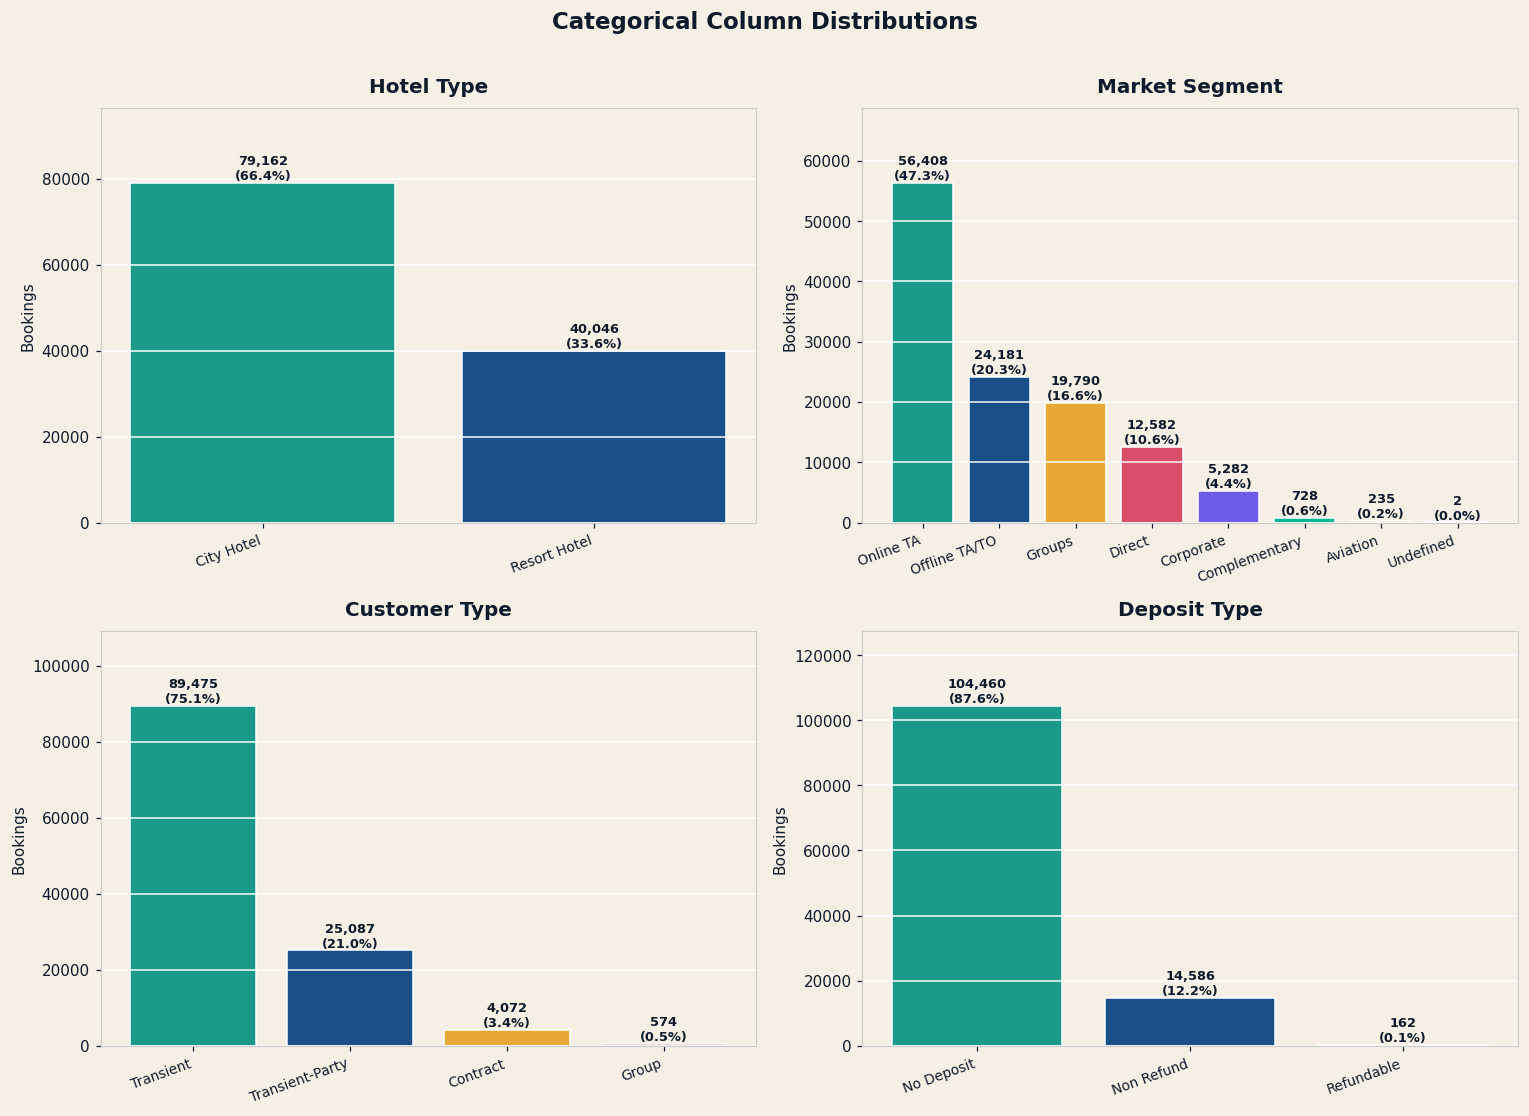

In [15]:
#Categorical Columns [Bar Chart]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor(SAND)
fig.suptitle('Categorical Column Distributions',
             fontsize=15, fontweight='bold', color=NAVY, y=1.01)

cat_config = [
    ('hotel',          'Hotel Type'),
    ('market_segment', 'Market Segment'),
    ('customer_type',  'Customer Type'),
    ('deposit_type',   'Deposit Type'),
]

palette = [TEAL, BLUE, AMBER, ROSE, '#6C5CE7', '#00B894', '#FDCB6E', '#E17055']

for ax, (col, title) in zip(axes.flat, cat_config):
    counts = df[col].value_counts()
    bars = ax.bar(counts.index, counts.values,
                  color=palette[:len(counts)], edgecolor='white')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                val + counts.max() * 0.01,
                f'{val:,}\n({val/len(df)*100:.1f}%)',
                ha='center', fontsize=8.5, color=NAVY, fontweight='bold')
    style_ax(ax, title, '', 'Bookings')
    ax.set_xticklabels(counts.index, rotation=20, ha='right', fontsize=9)
    ax.set_ylim(0, counts.max() * 1.22)

plt.tight_layout()
plt.show()

Outlier Detection

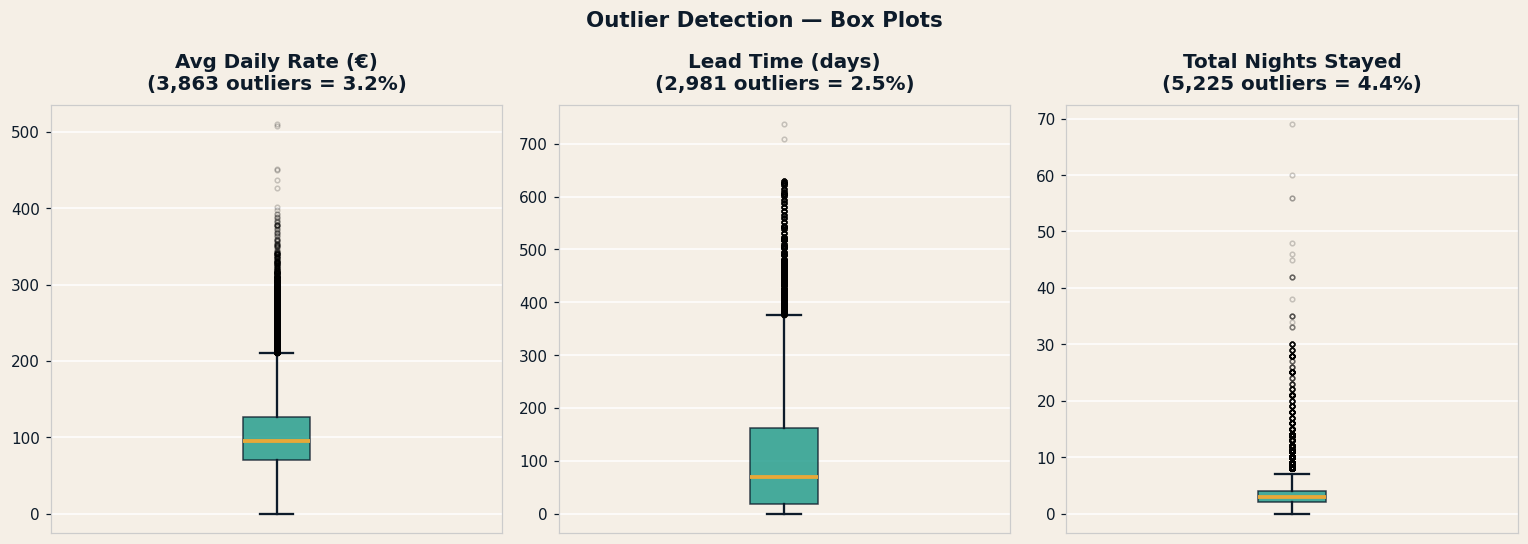

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.patch.set_facecolor(SAND)
fig.suptitle('Outlier Detection — Box Plots',
             fontsize=14, fontweight='bold', color=NAVY)

for ax, col, title in zip(axes,
    ['adr', 'lead_time', 'total_nights'],
    ['Avg Daily Rate (€)', 'Lead Time (days)', 'Total Nights Stayed']):

    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = len(df[(df[col] < q1-1.5*iqr) | (df[col] > q3+1.5*iqr)])

    ax.boxplot(df[col], patch_artist=True,
               boxprops     = dict(facecolor=TEAL, color=NAVY, alpha=0.8),
               medianprops  = dict(color=AMBER, linewidth=2.5),
               whiskerprops = dict(color=NAVY, linewidth=1.5),
               capprops     = dict(color=NAVY, linewidth=1.5),
               flierprops   = dict(marker='o', color=ROSE,
                                   alpha=0.2, markersize=3))
    style_ax(ax, f'{title}\n({n_out:,} outliers = {n_out/len(df)*100:.1f}%)')
    ax.set_xticks([])

plt.tight_layout()
plt.show()


Bivariate [Cancellation Rate by Category]

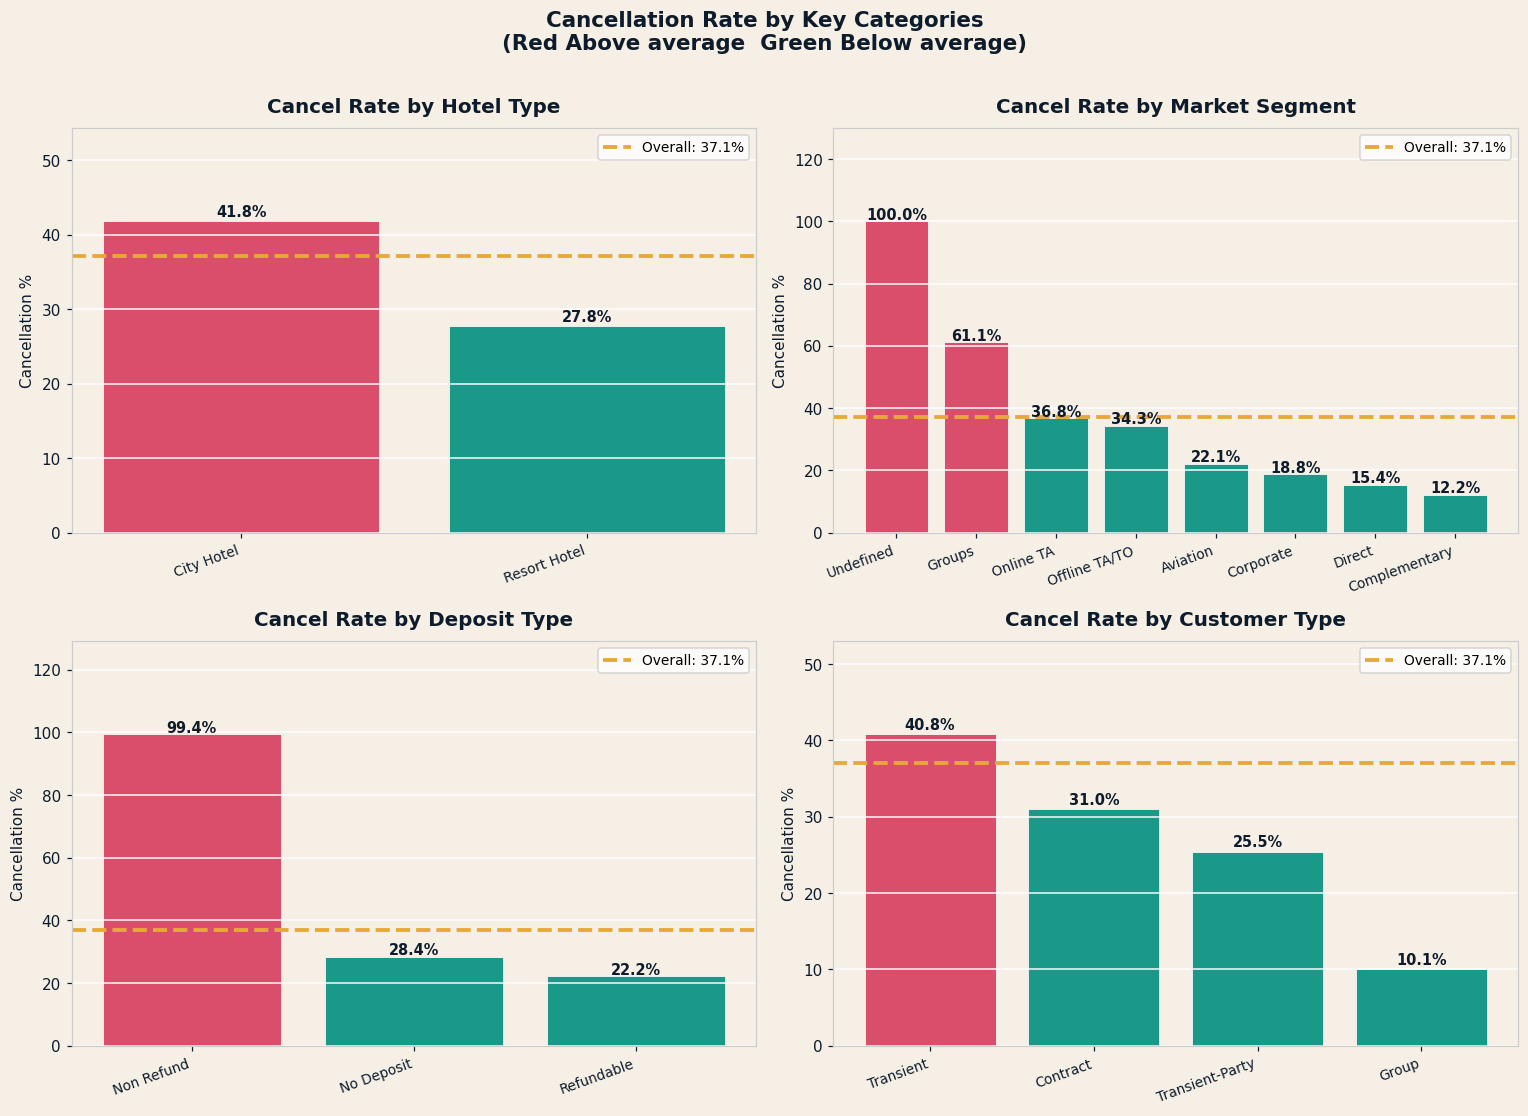

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor(SAND)
fig.suptitle('Cancellation Rate by Key Categories\n'
             '(Red Above average  Green Below average)',
             fontsize=14, fontweight='bold', color=NAVY, y=1.01)

overall_pct = df['is_canceled'].mean() * 100  # = 37.1%

for ax, (col, title) in zip(axes.flat, [
    ('hotel',          'Hotel Type'),
    ('market_segment', 'Market Segment'),
    ('deposit_type',   'Deposit Type'),
    ('customer_type',  'Customer Type'),
]):
    rates = df.groupby(col)['is_canceled'].mean().sort_values(ascending=False) * 100
    colors = [ROSE if v > overall_pct else TEAL for v in rates.values]

    bars = ax.bar(rates.index, rates.values,
                  color=colors, edgecolor='white', linewidth=0.5)
    ax.axhline(overall_pct, color=AMBER, linewidth=2.5,
               linestyle='--', label=f'Overall: {overall_pct:.1f}%')

    for bar, val in zip(bars, rates.values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.6,
                f'{val:.1f}%', ha='center', fontsize=9.5,
                fontweight='bold', color=NAVY)

    style_ax(ax, f'Cancel Rate by {title}', '', 'Cancellation %')
    ax.set_xticklabels(rates.index, rotation=20, ha='right', fontsize=9)
    ax.set_ylim(0, rates.max() * 1.3)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


Lead Time Predicts Cancellation

In [18]:
lead_analysis = (
    df.groupby('lead_bucket', observed=True)['is_canceled']
    .agg(cancel_rate='mean', booking_count='count')
    .reset_index()
)
lead_analysis['cancel_pct'] = lead_analysis['cancel_rate'] * 100

# Print table first
print("Lead Time vs Cancellation Rate:")
print("─" * 48)
for _, row in lead_analysis.iterrows():
    bar = '█' * int(row['cancel_pct'] / 4)
    print(f"  {str(row['lead_bucket']):<15} {row['cancel_pct']:5.1f}%  {bar}")



Lead Time vs Cancellation Rate:
────────────────────────────────────────────────
  ≤7 days          11.0%  ██
  8-30 days        27.9%  ██████
  31-90 days       37.7%  █████████
  91-180 days      44.7%  ███████████
  181-365 days     55.5%  █████████████
  >365 days        67.7%  ████████████████


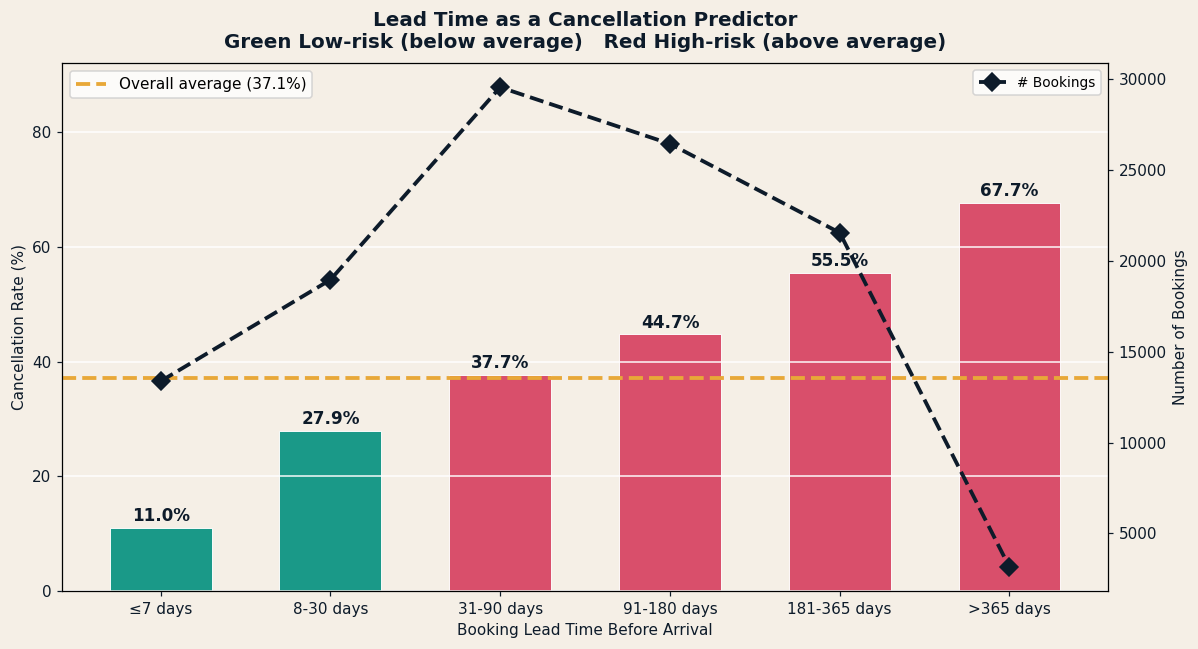

In [20]:
# Chart
fig, ax1 = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(SAND)

overall_pct = 37.1
bar_colors = [TEAL if p < overall_pct else ROSE
              for p in lead_analysis['cancel_pct']]

bars = ax1.bar(lead_analysis['lead_bucket'].astype(str),
               lead_analysis['cancel_pct'],
               color=bar_colors, edgecolor='white',
               linewidth=0.6, width=0.6)

ax1.axhline(overall_pct, color=AMBER, linewidth=2.5,
            linestyle='--', label=f'Overall average ({overall_pct}%)')

for bar, val in zip(bars, lead_analysis['cancel_pct']):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 1.2,
             f'{val:.1f}%', ha='center', fontsize=11,
             fontweight='bold', color=NAVY)

style_ax(ax1,
    'Lead Time as a Cancellation Predictor\n'
    'Green Low-risk (below average)   Red High-risk (above average)',
    'Booking Lead Time Before Arrival', 'Cancellation Rate (%)')
ax1.set_ylim(0, 92)
ax1.legend(fontsize=10, loc='upper left')

# Volume line on right axis
ax2 = ax1.twinx()
ax2.plot(lead_analysis['lead_bucket'].astype(str),
         lead_analysis['booking_count'],
         color=NAVY, marker='D', linewidth=2.5,
         markersize=8, linestyle='--', label='# Bookings')
ax2.set_ylabel('Number of Bookings', fontsize=10, color=NAVY)
ax2.tick_params(colors=NAVY)
ax2.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

**Insight 1 **                                                                
Lead Time Predicts Cancellation
Guests who book more than 90 days in advance cancel over 55% of the time, while last-minute bookings (≤7 days) cancel at just 11% — meaning the hotel's earliest bookings are its least reliable revenue.

Revenue by Market Segment

In [21]:
completed = df[df['is_canceled'] == 0].copy()

seg_summary = completed.groupby('market_segment').agg(
    avg_revenue  = ('total_revenue', 'mean'),
    avg_adr      = ('adr',           'mean'),
    avg_nights   = ('total_nights',  'mean'),
    booking_count= ('hotel',         'count')
).round(1).sort_values('avg_revenue', ascending=False)

# Add cancel rate from full dataset
seg_summary['cancel_pct'] = (
    df.groupby('market_segment')['is_canceled'].mean() * 100
).round(1)

print(seg_summary)


                avg_revenue  avg_adr  avg_nights  booking_count  cancel_pct
market_segment                                                             
Aviation             387.30   100.60        3.80            183       22.10
Direct               384.80   114.10        3.10          10648       15.40
Online TA            384.20   114.00        3.30          35673       36.80
Offline TA/TO        356.40    83.60        4.30          15880       34.30
Groups               242.90    77.30        3.20           7696       61.10
Corporate            134.70    67.30        2.00           4291       18.80
Complementary          7.50     3.10        1.70            639       12.20


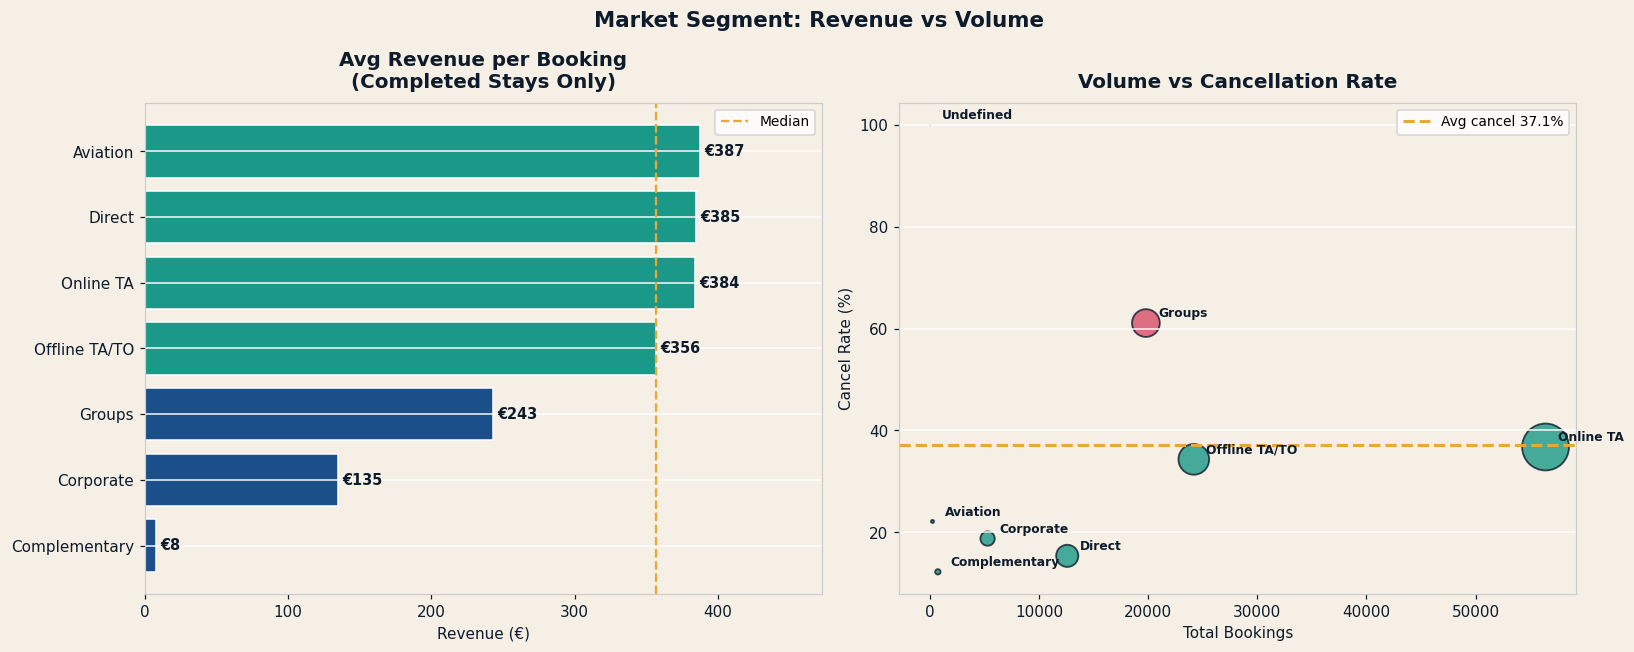

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor(SAND)
fig.suptitle('Market Segment: Revenue vs Volume',
             fontsize=14, fontweight='bold', color=NAVY)

# Left — avg revenue bar chart
seg_rev = seg_summary['avg_revenue'].sort_values(ascending=True)
bar_colors = [TEAL if v >= seg_rev.median() else BLUE for v in seg_rev]

bars = axes[0].barh(seg_rev.index, seg_rev.values,
                    color=bar_colors, edgecolor='white')
for bar, val in zip(bars, seg_rev.values):
    axes[0].text(val + 3, bar.get_y() + bar.get_height()/2,
                 f'€{val:,.0f}', va='center', fontsize=9.5,
                 fontweight='bold', color=NAVY)
style_ax(axes[0], 'Avg Revenue per Booking\n(Completed Stays Only)',
         'Revenue (€)', '')
axes[0].set_xlim(0, seg_rev.max() * 1.22)
axes[0].axvline(seg_rev.median(), color=AMBER, linestyle='--',
                linewidth=1.5, label=f'Median')
axes[0].legend(fontsize=9)

# Right — volume vs cancel scatter
seg_scatter = df.groupby('market_segment').agg(
    count      = ('hotel',       'count'),
    cancel_pct = ('is_canceled', lambda x: x.mean() * 100)
).reset_index()

bubble_colors = [ROSE if r > 37.1 else TEAL for r in seg_scatter['cancel_pct']]
axes[1].scatter(seg_scatter['count'], seg_scatter['cancel_pct'],
                s=seg_scatter['count']/60,
                c=bubble_colors, edgecolors=NAVY,
                linewidths=1.2, alpha=0.8)

axes[1].axhline(37.1, color=AMBER, linewidth=2,
                linestyle='--', label='Avg cancel 37.1%')
for _, row in seg_scatter.iterrows():
    axes[1].annotate(row['market_segment'],
                     (row['count'], row['cancel_pct']),
                     xytext=(8, 4), textcoords='offset points',
                     fontsize=8, color=NAVY, fontweight='bold')

style_ax(axes[1], 'Volume vs Cancellation Rate',
         'Total Bookings', 'Cancel Rate (%)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

** Insight 2 **                            
Revenue by Market Segment
Despite Online TA dominating with 47% of all bookings, Direct and Aviation segments match it almost exactly on revenue per booking (≈€385) while carrying far lower cancel rates — 15.4% and 22.1% vs Online TA's 36.8% — making them significantly more valuable per booking.

Repeat Guest Loyalty

In [24]:
repeat_summary = df.groupby('guest_type').agg(
    cancel_pct   = ('is_canceled',                lambda x: x.mean()*100),
    avg_adr      = ('adr',                        'mean'),
    avg_nights   = ('total_nights',               'mean'),
    avg_requests = ('total_of_special_requests',  'mean'),
    count        = ('hotel',                      'count')
).round(2)

print(repeat_summary)

new_rate    = repeat_summary.loc['New Guest',    'cancel_pct']
repeat_rate = repeat_summary.loc['Repeat Guest', 'cancel_pct']
print(f"\n New guests cancel {new_rate/repeat_rate:.1f}× more often than repeat guests")


              cancel_pct  avg_adr  avg_nights  avg_requests   count
guest_type                                                         
New Guest          37.81   103.11        3.47          0.57  115454
Repeat Guest       14.65    65.41        1.95          0.63    3754

 New guests cancel 2.6× more often than repeat guests


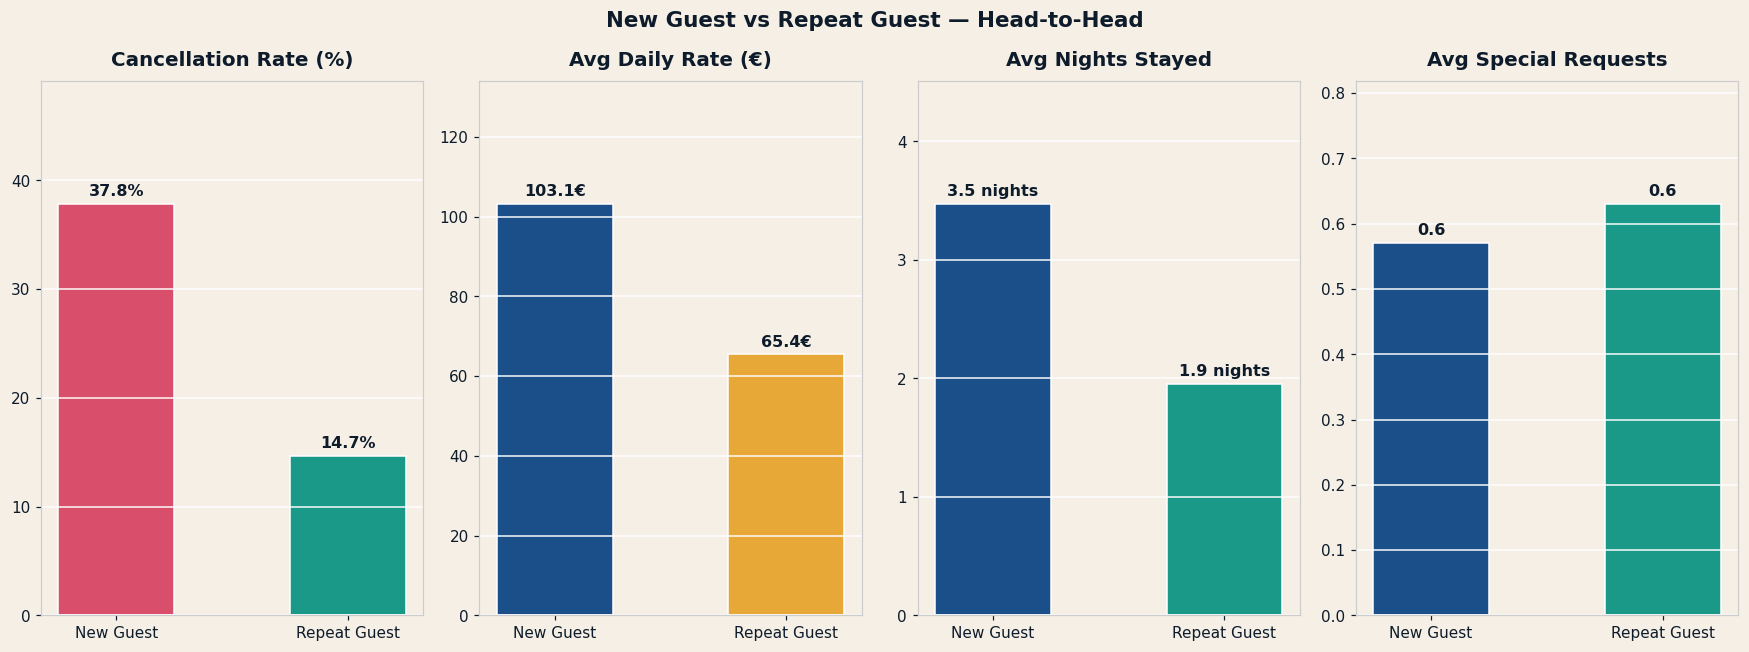

In [25]:
fig, axes = plt.subplots(1, 4, figsize=(16, 6))
fig.patch.set_facecolor(SAND)
fig.suptitle('New Guest vs Repeat Guest — Head-to-Head',
             fontsize=14, fontweight='bold', color=NAVY)

metrics   = ['cancel_pct','avg_adr','avg_nights','avg_requests']
titles    = ['Cancellation Rate (%)','Avg Daily Rate (€)',
             'Avg Nights Stayed','Avg Special Requests']
pal_pairs = [[ROSE,TEAL],[BLUE,AMBER],[BLUE,TEAL],[BLUE,TEAL]]
suffixes  = ['%','€',' nights','']

for ax, m, title, pal, suf in zip(axes, metrics, titles, pal_pairs, suffixes):
    vals = repeat_summary[m]
    bars = ax.bar(repeat_summary.index, vals,
                  color=pal, edgecolor='white', width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                val + vals.max() * 0.02,
                f'{val:.1f}{suf}', ha='center', fontsize=10.5,
                fontweight='bold', color=NAVY)
    style_ax(ax, title)
    ax.set_ylim(0, vals.max() * 1.3)

plt.tight_layout()
plt.show()

** Insight 3 **                          
Repeat Guest Loyalty
Repeat guests make up just 3.2% of all bookings yet cancel at only 14.7% compared to 37.8% for new guests — if the hotel could convert even 5% more guests into repeat visitors, it would meaningfully cut its overall cancellation rate without acquiring a single new customer.

Seasonal Pricing Heatmap

In [26]:
completed = df[df['is_canceled'] == 0]
pivot = completed.groupby(['hotel','arrival_date_month'])['adr'].mean().unstack(0).round(1)

print("Avg Daily Rate (€) by Month & Hotel Type:")
print(pivot.to_string())

for hotel in ['City Hotel','Resort Hotel']:
    peak   = pivot[hotel].idxmax()
    trough = pivot[hotel].idxmin()
    swing  = pivot[hotel].max() - pivot[hotel].min()
    print(f"\n{hotel}:")
    print(f"  Peak   → {peak}   €{pivot[hotel].max():.0f}/night")
    print(f"  Trough → {trough} €{pivot[hotel].min():.0f}/night")
    print(f"  Swing  → €{swing:.0f} ({swing/pivot[hotel].min()*100:.0f}% variation)")


Avg Daily Rate (€) by Month & Hotel Type:
hotel               City Hotel  Resort Hotel
arrival_date_month                          
January                  82.30         48.80
February                 86.50         54.10
March                    90.70         57.10
April                   112.00         75.90
May                     120.70         76.70
June                    117.90        108.00
July                    115.80        150.10
August                  118.70        181.20
September               112.80         96.40
October                 102.00         61.80
November                 86.90         48.70
December                 88.40         68.40

City Hotel:
  Peak   → May   €121/night
  Trough → January €82/night
  Swing  → €38 (47% variation)

Resort Hotel:
  Peak   → August   €181/night
  Trough → November €49/night
  Swing  → €132 (272% variation)


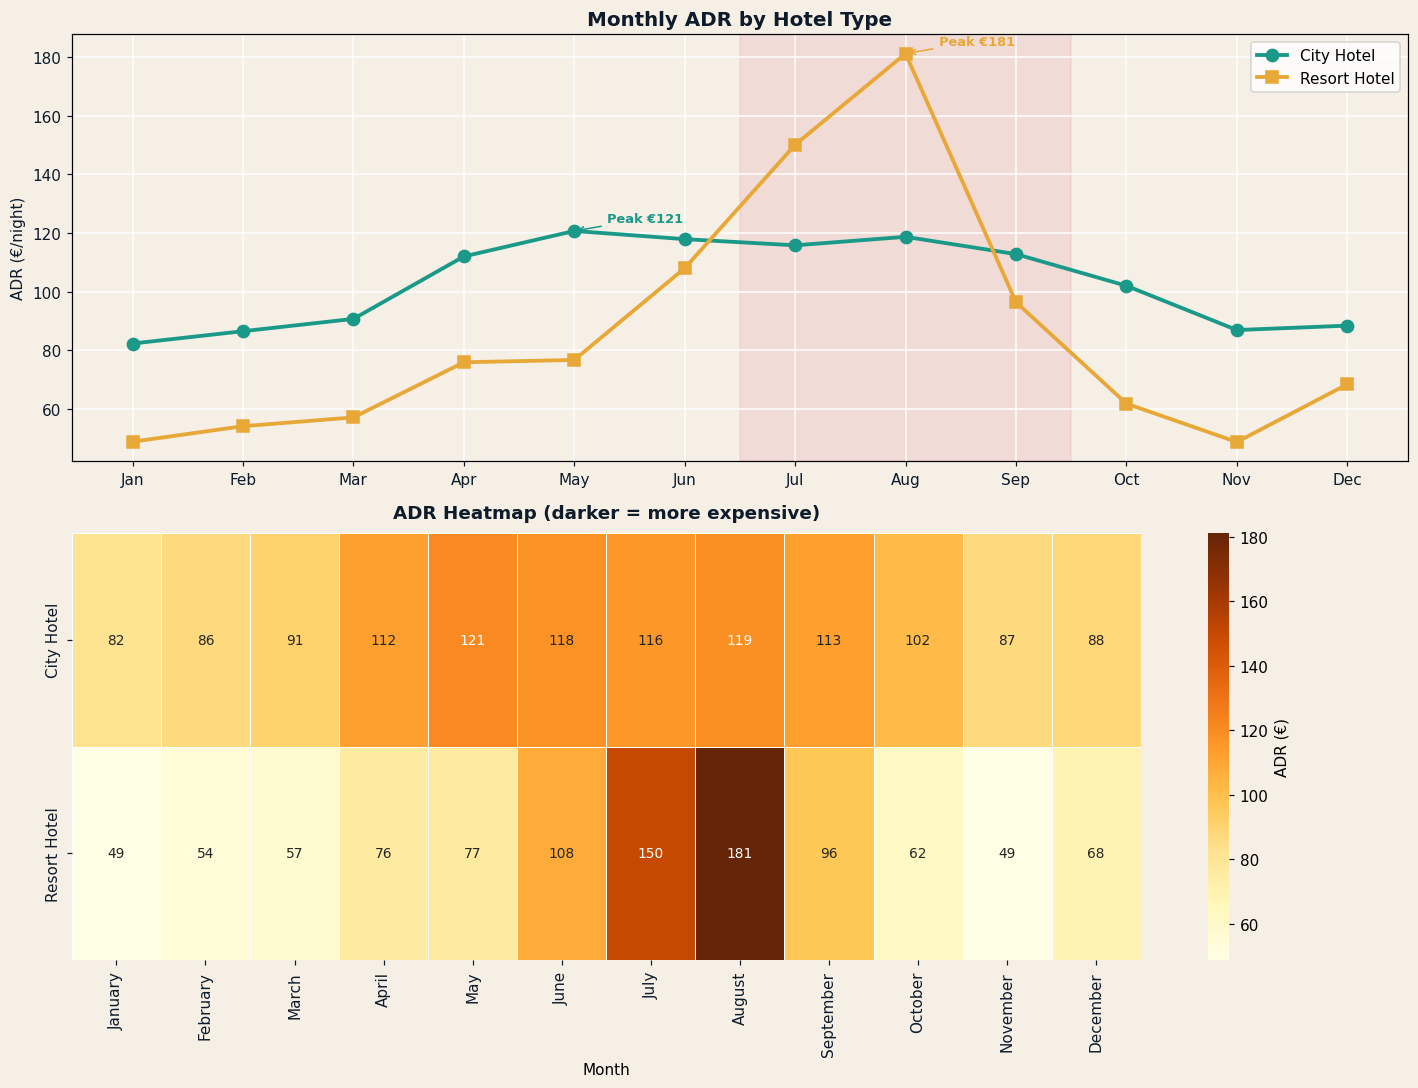

In [27]:
fig, axes = plt.subplots(2, 1, figsize=(13, 10))
fig.patch.set_facecolor(SAND)

month_short = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

# Line chart
for hotel, color, marker in zip(
    ['City Hotel','Resort Hotel'], [TEAL, AMBER], ['o','s']):
    vals = pivot[hotel].values
    axes[0].plot(range(12), vals, marker=marker, color=color,
                 linewidth=2.5, markersize=8, label=hotel)
    peak_idx = vals.argmax()
    axes[0].annotate(f'Peak €{vals[peak_idx]:.0f}',
                     xy=(peak_idx, vals[peak_idx]),
                     xytext=(peak_idx+0.3, vals[peak_idx]+3),
                     fontsize=8.5, color=color, fontweight='bold',
                     arrowprops=dict(arrowstyle='->', color=color))

axes[0].set_xticks(range(12))
axes[0].set_xticklabels(month_short, color=NAVY)
axes[0].set_facecolor(SAND)
axes[0].set_title('Monthly ADR by Hotel Type',
                  fontsize=13, fontweight='bold', color=NAVY)
axes[0].set_ylabel('ADR (€/night)', fontsize=10, color=NAVY)
axes[0].tick_params(colors=NAVY)
axes[0].legend(fontsize=10)
axes[0].grid(color='white', linewidth=1.2, alpha=0.8)
axes[0].axvspan(5.5, 8.5, alpha=0.12, color=ROSE)

# Heatmap
sns.heatmap(pivot.T, ax=axes[1], cmap='YlOrBr',
            annot=True, fmt='.0f', linewidths=0.5,
            cbar_kws={'label':'ADR (€)'},
            annot_kws={'size': 9})
axes[1].set_title('ADR Heatmap (darker = more expensive)',
                  fontsize=12, fontweight='bold', color=NAVY, pad=10)
axes[1].set_xlabel('Month', fontsize=10)
axes[1].set_ylabel('')
axes[1].tick_params(colors=NAVY)

plt.tight_layout()
plt.show()

** Insight 4 **                                
Seasonal Pricing
Resort Hotels swing from €49/night in November to €181/night in August — a 271% seasonal gap — while City Hotels stay far more stable (€82 to €121), suggesting Resort Hotels are heavily dependent on summer demand and are leaving revenue on the table during shoulder months like April and October.

Room Assignment Mismatch

In [28]:
overall_mm = (~df['room_match']).mean() * 100
print(f"Overall room mismatch rate: {overall_mm:.1f}%")
print(f"  → {(~df['room_match']).sum():,} of {len(df):,} bookings\n")

mismatch_seg = (
    df.groupby('market_segment')['room_match']
    .agg(lambda x: (~x).mean() * 100)
    .sort_values(ascending=False)
    .round(1)
)
print("Mismatch Rate by Segment:")
for seg, val in mismatch_seg.items():
    flag = '⚠️ ' if val > overall_mm else '✅ '
    bar  = '█' * int(val / 2)
    print(f"  {flag}{seg:<20} {val:5.1f}%  {bar}")


Overall room mismatch rate: 12.4%
  → 14,795 of 119,208 bookings

Mismatch Rate by Segment:
  ⚠️ Complementary         33.2%  ████████████████
  ⚠️ Corporate             28.1%  ██████████████
  ⚠️ Direct                16.8%  ████████
  ⚠️ Offline TA/TO         14.9%  ███████
  ✅ Online TA              9.7%  ████
  ✅ Groups                 9.5%  ████
  ✅ Aviation               8.5%  ████
  ✅ Undefined              0.0%  


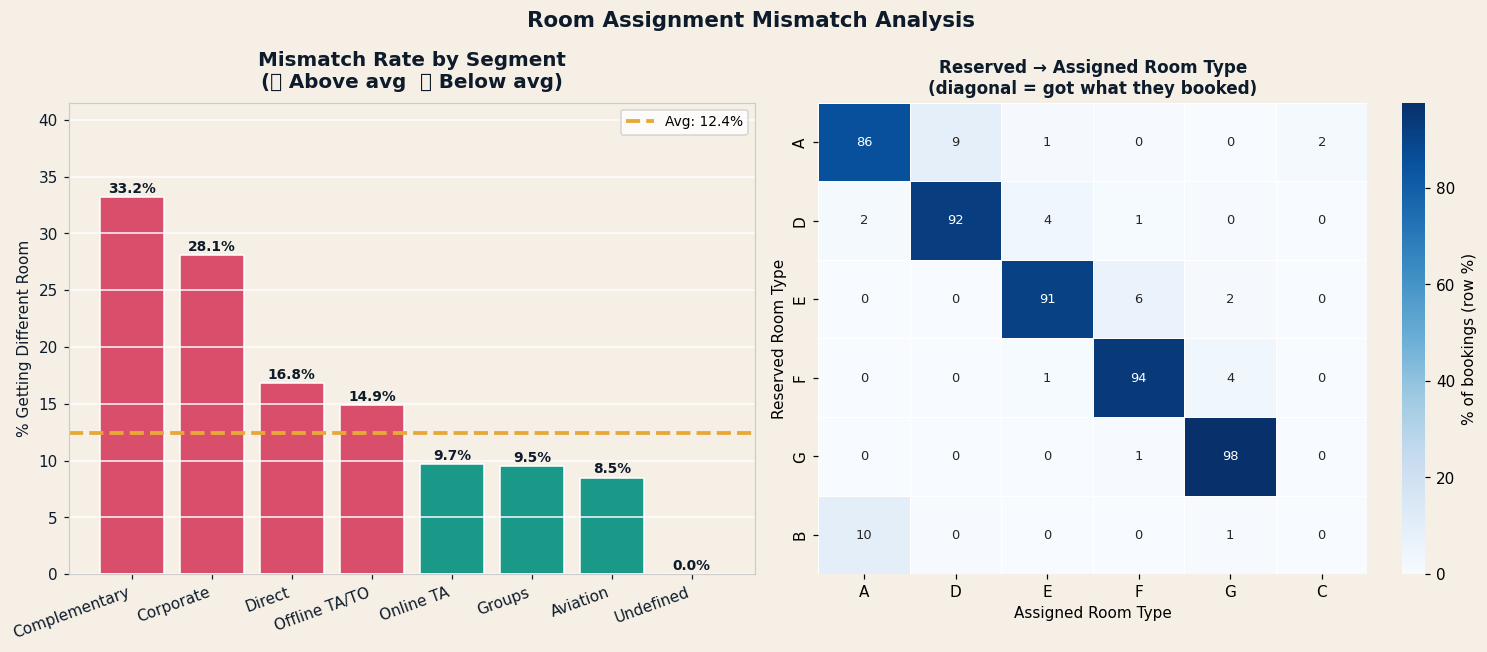

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(SAND)
fig.suptitle('Room Assignment Mismatch Analysis',
             fontsize=14, fontweight='bold', color=NAVY)

avg_mm = (~df['room_match']).mean() * 100

# Bar chart by segment
bar_colors = [ROSE if v > avg_mm else TEAL for v in mismatch_seg.values]
bars = axes[0].bar(mismatch_seg.index, mismatch_seg.values,
                   color=bar_colors, edgecolor='white')
axes[0].axhline(avg_mm, color=AMBER, linewidth=2.5,
                linestyle='--', label=f'Avg: {avg_mm:.1f}%')
for bar, val in zip(bars, mismatch_seg.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.4,
                 f'{val:.1f}%', ha='center', fontsize=9,
                 fontweight='bold', color=NAVY)
style_ax(axes[0],
    'Mismatch Rate by Segment\n(🔴 Above avg  🟢 Below avg)',
    '', '% Getting Different Room')
axes[0].set_xticklabels(mismatch_seg.index, rotation=20, ha='right')
axes[0].set_ylim(0, mismatch_seg.max() * 1.25)
axes[0].legend(fontsize=9)

# Heatmap — what room did they get vs what they booked?
top_reserved = df['reserved_room_type'].value_counts().head(6).index
top_assigned  = df['assigned_room_type'].value_counts().head(6).index
room_cross = pd.crosstab(df['reserved_room_type'],
                         df['assigned_room_type'],
                         normalize='index') * 100
room_cross = room_cross.loc[top_reserved, top_assigned]

sns.heatmap(room_cross, ax=axes[1], cmap='Blues',
            annot=True, fmt='.0f', linewidths=0.5,
            cbar_kws={'label': '% of bookings (row %)'},
            annot_kws={'size': 8.5})
axes[1].set_title('Reserved → Assigned Room Type\n(diagonal = got what they booked)',
                  fontsize=11, fontweight='bold', color=NAVY)
axes[1].set_xlabel('Assigned Room Type', fontsize=10)
axes[1].set_ylabel('Reserved Room Type', fontsize=10)

plt.tight_layout()
plt.show()

** Insight 5 **                         
Room Assignment Mismatch
1 in 8 guests (12.4%) receives a different room to what they booked, with Complementary and Corporate segments hit hardest at 33% and 28% respectively — an operational gap that directly drives negative reviews and is entirely within the hotel's control to fix.

Correlation Heatmap

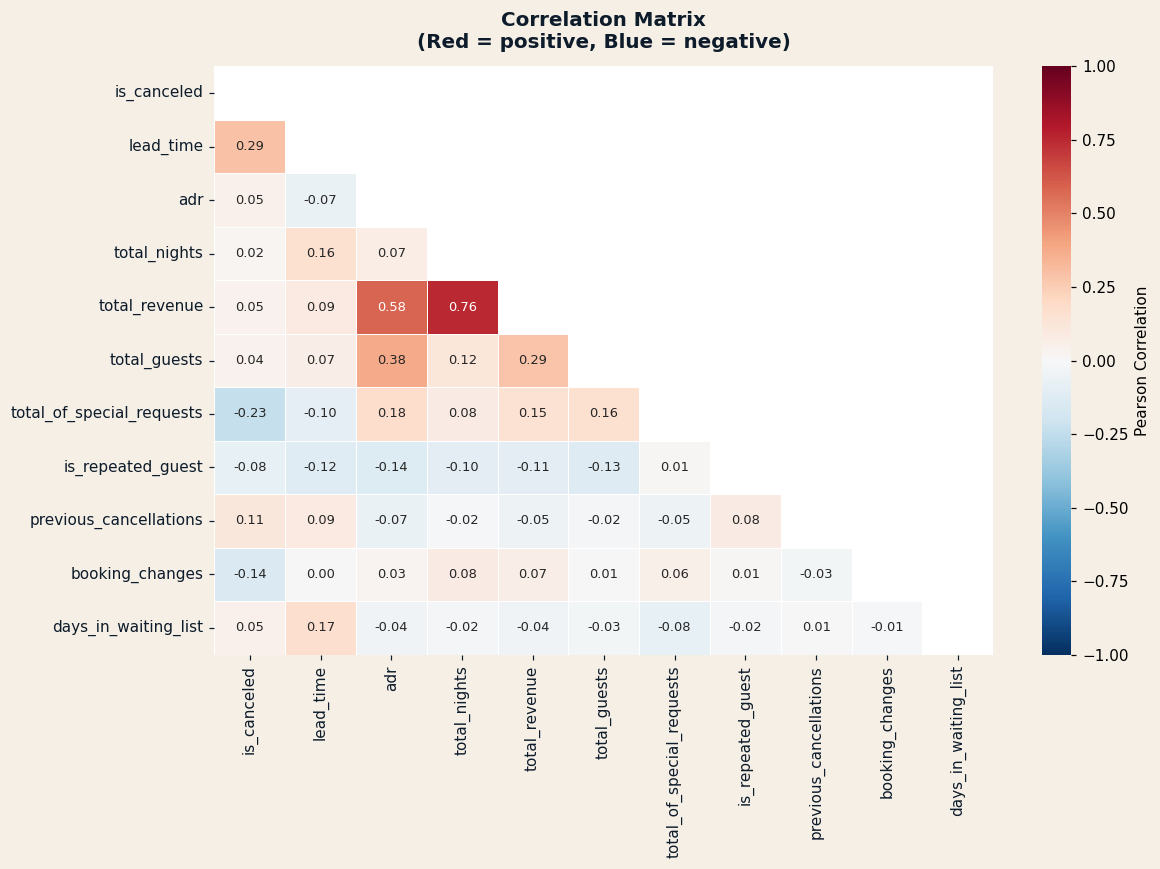

Variables ranked by correlation with is_canceled:
──────────────────────────────────────────────────
  lead_time                           +0.293  (↑ positive)
  total_of_special_requests           -0.235  (↓ negative)
  booking_changes                     -0.145  (↓ negative)
  previous_cancellations              +0.110  (↑ positive)
  is_repeated_guest                   -0.084  (↓ negative)
  days_in_waiting_list                +0.054  (↑ positive)
  adr                                 +0.048  (↑ positive)
  total_revenue                       +0.046  (↑ positive)
  total_guests                        +0.045  (↑ positive)
  total_nights                        +0.019  (↑ positive)


In [30]:
num_cols = ['is_canceled','lead_time','adr','total_nights','total_revenue',
            'total_guests','total_of_special_requests','is_repeated_guest',
            'previous_cancellations','booking_changes','days_in_waiting_list']

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
fig.patch.set_facecolor(SAND)

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, ax=ax, mask=mask, cmap='RdBu_r',
            center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', linewidths=0.5,
            cbar_kws={'label': 'Pearson Correlation'},
            annot_kws={'size': 8.5})

ax.set_title('Correlation Matrix\n(Red = positive, Blue = negative)',
             fontsize=13, fontweight='bold', color=NAVY, pad=12)
ax.tick_params(colors=NAVY)
plt.tight_layout()
plt.show()

# Print ranked correlations with is_canceled
print("Variables ranked by correlation with is_canceled:")
print("─" * 50)
ranked = corr['is_canceled'].drop('is_canceled').sort_values(key=abs, ascending=False)
for col, val in ranked.items():
    direction = '↑ positive' if val > 0 else '↓ negative'
    print(f"  {col:<35} {val:+.3f}  ({direction})")
